<a href="https://colab.research.google.com/github/binsue0/.github/blob/main/ML_day2/2_1_decision_tree_and_ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree and Ensemble

ref: https://github.com/rickiepark/handson-ml2

## 주요 내용
- Decision Tree
- Ensemble(bagging, boosting)

#  Decision Tree

**결정 트리(Decision Tree)**는 특성 공간을 축에 수직인 경계로 재귀적으로 분할하여 분류·회귀를 수행하는 모델이다. 각 내부 노드는 하나의 특성에 대한 임계값 조건을, 리프 노드는 예측값을 나타낸다.

분류 트리는 각 분할에서 자식 노드의 **불순도(impurity)** 가중합을 최소화하는 특성·임계값을 선택한다. 지니 불순도는 다음과 같이 정의된다.

$$G_i = 1 - \sum_{k=1}^{n} p_{i,k}^2$$

여기서 $p_{i,k}$는 노드 $i$에서 클래스 $k$의 비율이다. 이 탐욕적 분할을 정지 조건(최대 깊이, 최소 샘플 수 등)에 도달할 때까지 반복한다. `max_depth`는 트리의 최대 깊이를 제한하여 과적합을 억제하는 정규화 하이퍼파라미터이다.

In [1]:
# 파이썬 ≥3.5 필수
import sys
assert sys.version_info >= (3, 5)

# 사이킷런 ≥0.20 필수
import sklearn
assert sklearn.__version__ >= "0.20"

# 공통 모듈 임포트
import numpy as np
import os

# 노트북 실행 결과를 동일하게 유지하기 위해
np.random.seed(42)

# 깔끔한 그래프 출력을 위해
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# 훈련과 시각화

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data[:, 2:] # 꽃잎 길이와 너비
y = iris.target
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42) #설정하지 않았으면 gini(Gini impurity)
tree_clf.fit(X, y)

DecisionTreeClassifier(max_depth=3, random_state=42)

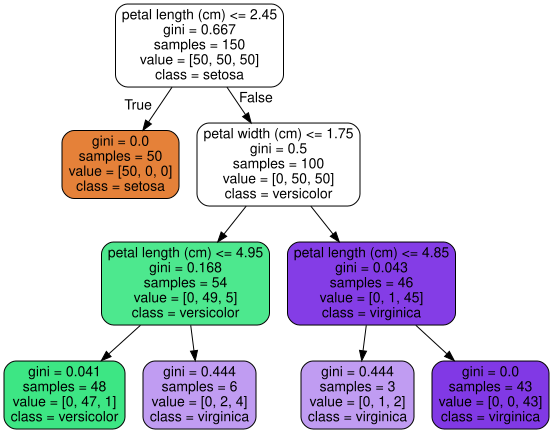

In [3]:
from graphviz import Source
from sklearn.tree import export_graphviz #시각화 툴 (아래 tree를 보기 쉽게 그려줌)

graph = export_graphviz(
        tree_clf,
        feature_names=iris.feature_names[2:],
        class_names=iris.target_names,
        rounded=True, # 노드 모서리를 둥글게
        filled=True # 노드 색상을 채움 (클래스별로 다르게)
        )

Source(graph) ##fetal length와 width만을 가지고 분류하는 DT를 시각화

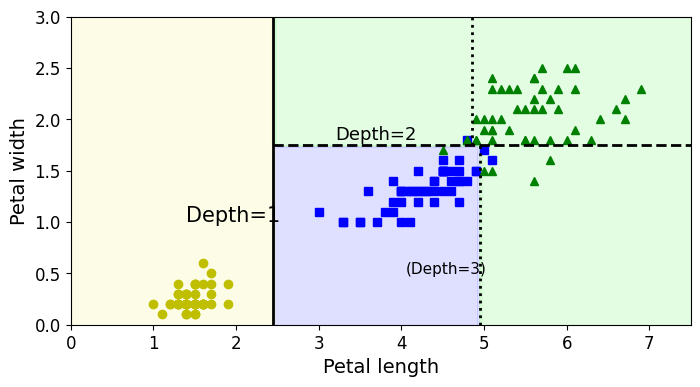

In [4]:
# 결정 경계 시각화
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, axes=[0, 7.5, 0, 3], iris=True, legend=False, plot_training=True):
    # 결정 경계는 보통 격자점을 미리 지정하고, 그 격자점에서 예측을 수행하여 시각화
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]

    y_pred = clf.predict(X_new).reshape(x1.shape) #predict 함수를 사용해서 모든 격자점에 대해 y_prediction 값을 얻음

    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap) # contourf는 같은 y_prediction을 지니는 격자점을 이어 등고선을 만들고 색으로 구분
    if not iris:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    if plot_training:
        plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
        plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
        plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Iris virginica")
        plt.axis(axes)
    if iris:
        plt.xlabel("Petal length", fontsize=14)
        plt.ylabel("Petal width", fontsize=14)
    else:
        plt.xlabel(r"$x_1$", fontsize=18)
        plt.ylabel(r"$x_2$", fontsize=18, rotation=0)
    if legend:
        plt.legend(loc="lower right", fontsize=14)

plt.figure(figsize=(8, 4))

plot_decision_boundary(tree_clf, X, y) ## decision boundary 그려줌 (위의 plot_decision_boundary 함수 활용)

plt.plot([2.45, 2.45], [0, 3], "k-", linewidth=2) #위의 노트북 cell에서 결과로 나타난 트리 분기 기준을 시각화
plt.plot([2.45, 7.5], [1.75, 1.75], "k--", linewidth=2)
plt.plot([4.95, 4.95], [0, 1.75], "k:", linewidth=2) 
plt.plot([4.85, 4.85], [1.75, 3], "k:", linewidth=2)
plt.text(1.40, 1.0, "Depth=1", fontsize=15)
plt.text(3.2, 1.80, "Depth=2", fontsize=13)
plt.text(4.05, 0.5, "(Depth=3)", fontsize=11)

plt.show()

# 클래스와 클래스 확률을 예측하기

결정 트리는 입력 샘플이 도달한 리프 노드의 클래스별 훈련 샘플 비율을 클래스 확률로 반환한다. 예측 클래스는 이 확률이 최대인 클래스로 결정된다.

In [5]:
tree_clf.predict_proba([[5, 1.5]]) # 꽃잎 길이 5cm, 너비 1.5cm인 꽃의 클래스 확률을 예측

array([[0.        , 0.33333333, 0.66666667]])

In [6]:
tree_clf.predict([[5, 1.5]]) # 꽃잎 길이 5cm, 너비 1.5cm인 꽃의 클래스 예측 (베이즈 결정 규칙에 따라 확률이 가장 높은 클래스로 예측함)

array([2])

# 회귀 트리

**회귀 트리(Regression Tree)**는 분할 기준으로 불순도 대신 평균제곱오차(MSE)를 사용한다. 각 분할은 자식 노드 내 타깃값의 MSE 가중합을 최소화하도록 선택되며, 리프 노드의 예측값은 해당 노드에 속한 훈련 샘플 타깃값의 평균이다. 따라서 예측 함수는 구간별 상수(계단) 형태를 가진다.

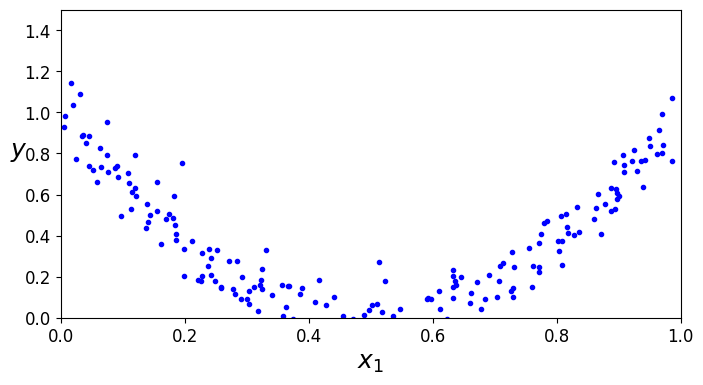

In [7]:
# 2차식으로 만든 데이터셋 + 잡음
np.random.seed(42)
m = 200
X = np.random.rand(m, 1)
y = 4 * (X - 0.5) ** 2
y = y + np.random.randn(m, 1) / 10

plt.figure(figsize=(8, 4))
plt.plot(X, y, "b.")
plt.xlabel(r"$x_1$", fontsize=18)
plt.ylabel(r"$y$", fontsize=18, rotation=0)
plt.axis([0, 1, 0, 1.5])
plt.show()

In [8]:
from sklearn.tree import DecisionTreeRegressor

tree_reg1 = DecisionTreeRegressor(random_state=42, max_depth=2)
tree_reg2 = DecisionTreeRegressor(random_state=42, max_depth=3)
tree_reg1.fit(X, y)
tree_reg2.fit(X, y)

DecisionTreeRegressor(max_depth=3, random_state=42)

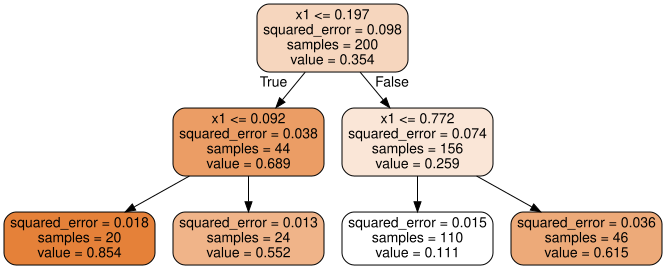

In [ ]:
graph = export_graphviz(
        tree_reg1,
        feature_names=["x1"],
        rounded=True,
        filled=True
        )
Source(graph)
# gini와 class가 표시되던 분류 트리와 달리
# squared_error(평균 제곱 오차)와 value(해당 노드의 평균 예측값)가 표시됨

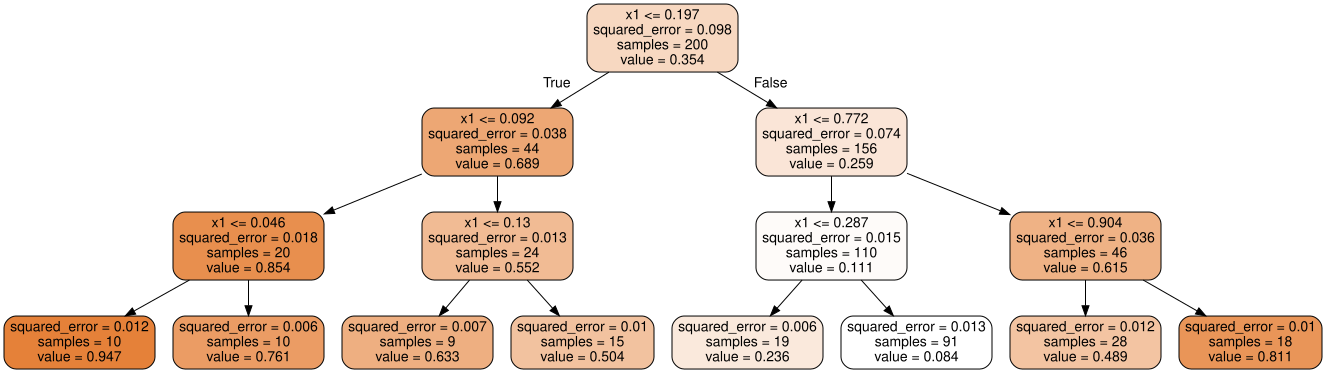

In [10]:
graph = export_graphviz(
        tree_reg2,
        feature_names=["x1"],
        rounded=True,
        filled=True
        )
Source(graph)

# Ensemble

**앙상블(Ensemble)**은 여러 개의 예측기를 결합하여 단일 예측기보다 나은 일반화 성능을 얻는 방법이다. 개별 예측기의 오차가 서로 독립적일수록 결합 효과가 커진다. 대표적으로 예측기를 병렬로 학습하는 **배깅(bagging)**과 순차적으로 학습하는 **부스팅(boosting)**이 있다.

In [11]:
# 파이썬 ≥3.5 필수
import sys
assert sys.version_info >= (3, 5)

# 사이킷런 ≥0.20 필수
import sklearn
assert sklearn.__version__ >= "0.20"

# 공통 모듈 임포트
import numpy as np
import os

import time

# 노트북 실행 결과를 동일하게 유지하기 위해
np.random.seed(42)

# 깔끔한 그래프 출력을 위해
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier( # 배깅은 원본 훈련 데이터에서 중복을 허용하여 여러 개의 서브셋을 만들고, 각 서브셋으로 개별 모델을 훈련시킨 후 예측 결과를 집계하는 방식임
    DecisionTreeClassifier(random_state=42), n_estimators=500,
    max_samples=100, bootstrap=True, random_state=42)
# n_estimators: 앙상블에 포함될 기본 추정기의 수
# max_samples: 각 기본 추정기에 대해 훈련에 사용할 샘플의 수
# bootstrap=True: 부트스트랩 샘플링(중복 허용 복원 추출)을 사용

bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

**배깅(Bagging, Bootstrap Aggregating)**은 원본 훈련 세트에서 복원 추출(부트스트랩)로 여러 서브셋을 생성하고, 각 서브셋으로 동일한 알고리즘의 예측기를 독립적으로 학습한 뒤, 분류는 다수결·회귀는 평균으로 예측을 집계한다. 예측기 간 다양성을 통해 분산(variance)을 감소시킨다. (복원 추출 없이 중복을 허용하지 않는 경우는 페이스팅(pasting)이라 한다.)

In [14]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred)) #bagging이 decision tree보다 test 성능이 좋다는 것을 볼 수 있다!

0.904


In [15]:
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
print(accuracy_score(y_test, y_pred_tree)) #decision tree의 성능은 85%

0.856


In [ ]:
# 결정 경계 시각화
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, axes=[-1.5, 2.45, -1, 1.5], alpha=0.5, contour=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if contour:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", alpha=alpha)
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", alpha=alpha)
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)

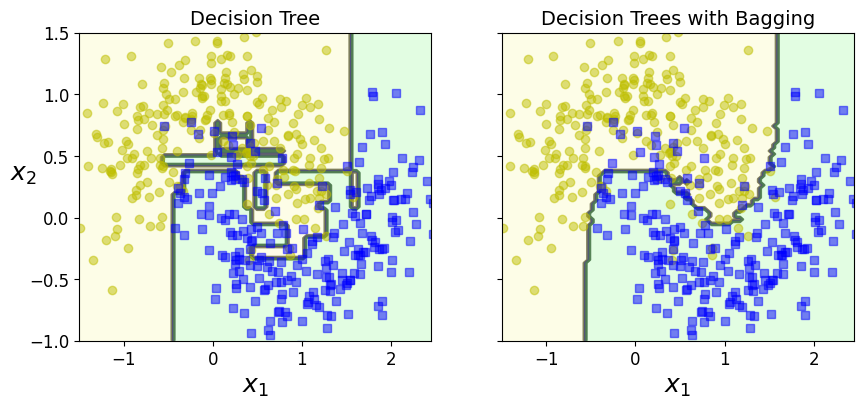

In [ ]:
fix, axes = plt.subplots(ncols=2, figsize=(10,4), sharey=True) #bagging이 decision bound가 좀 더 smooth함, 즉 과적합이 DT보다 덜 되었고, 일반화 성능이 뛰어남
plt.sca(axes[0])
plot_decision_boundary(tree_clf, X, y)
plt.title("Decision Tree", fontsize=14)
plt.sca(axes[1])
plot_decision_boundary(bag_clf, X, y)
plt.title("Decision Trees with Bagging", fontsize=14)
plt.ylabel("")
plt.show()

# Random Forest

**랜덤 포레스트(Random Forest)**는 결정 트리를 기본 예측기로 하는 배깅의 확장이다. 부트스트랩 샘플링에 더해, 각 노드 분할 시 전체 특성 중 무작위로 선택한 부분집합만 후보로 고려한다. 이로써 트리 간 상관을 낮춰 앙상블의 분산 감소 효과를 강화한다. `max_features`는 각 분할에서 고려할 특성 수를 지정한다.

**특성 중요도(feature importance)**는 각 특성이 트리 전반에서 불순도를 감소시킨 정도의 가중 평균으로 산출된다.

In [ ]:
# bagging과 RF를 비교
start = time.time()

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_leaf_nodes=16, random_state=42),
    n_estimators=500, max_samples=1.0, bootstrap=True, random_state=42)
# max_leaf_nodes=16: 최대 리프 노드 수를 16으로 제한하여 모델의 복잡도를 조절
# max_samples=1.0: 각 기본 추정기에 대해 훈련에 사용할 샘플의 비율을 100%로 설정

bag_clf.fit(X_train, y_train)
print("time :", time.time() - start)  # 현재시각 - 시작시간 = 실행 시간

y_pred = bag_clf.predict(X_test)
print(y_pred)

time : 1.1478257179260254
[1 0 0 1 1 1 0 0 0 0 1 0 1 1 1 0 0 1 1 0 0 1 1 0 0 0 1 0 1 0 1 1 0 0 1 0 0
 1 1 1 0 1 0 0 0 0 1 1 1 1 1 1 0 0 1 0 1 1 0 1 0 1 1 0 1 0 0 0 0 1 0 0 1 1
 0 0 1 1 0 0 1 1 1 0 1 1 1 0 1 1 1 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 1 1 0
 0 0 1 1 0 0 0 0 1 1 1 0 0 0]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

start = time.time()
rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, random_state=42,max_features=2)
# n_estimators=500: 500개의 결정 트리를 사용하여 앙상블
# max_features=2: 각 노드에서 분할을 고려할 특성의 수를 2로 설정
# max_leaf_nodes=16: 최대 리프 노드 수를 16으로 제한하여 모델의 복잡도를 조절

rnd_clf.fit(X_train, y_train)
print("time :", time.time() - start)  # 현재시각 - 시작시간 = 실행 시간

y_pred_rf = rnd_clf.predict(X_test)
print(y_pred_rf)
print(accuracy_score(y_test, y_pred_rf))
# 두 셀의 실행 시간(time)을 비교하면, 특성 선택 과정이 추가되었음에도 불구하고 Random Forest가 Bagging보다 종종 더 빠르게 훈련될 수 있음을 보여줍니다. 
# accuracy_score 결과(0.912)는 배깅과 유사하거나 약간 더 높은 성능을 보입니다.

time : 0.748058557510376
[1 0 0 1 1 1 0 0 0 0 1 0 1 1 1 0 0 1 1 0 0 1 1 0 0 0 1 0 1 0 1 1 0 0 1 0 0
 1 1 1 0 1 0 0 0 0 1 1 1 1 1 1 0 0 1 0 1 1 0 1 0 1 1 0 1 0 0 0 0 1 0 0 1 1
 0 0 1 1 0 0 1 1 1 0 1 1 1 0 1 1 1 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 1 1 0
 0 0 1 1 0 0 0 0 1 1 1 0 0 0]
0.912


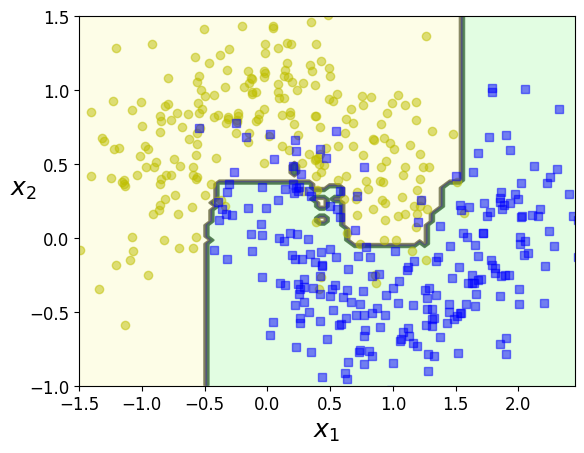

In [20]:
plot_decision_boundary(rnd_clf, X, y)


In [21]:
np.sum(y_pred == y_pred_rf) / len(y_pred)  #거의 예측이 동일합니다.


1.0

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris["data"], iris["target"])
for name, score in zip(iris["feature_names"], rnd_clf.feature_importances_):
    print(name, score)

# Random Forest는 특성 중요도를 계산할 때, 각 특성이 얼마나 많은 트리에서 분할 기준으로 사용되었는지를 기반으로 계산
# petal length (cm) 0.446970
# petal width (cm) 0.453205
# petal length와 petal width가 가장 중요한 특성으로 나타나며, 이는 꽃잎의 길이와 너비가 붓꽃 분류에 가장 큰 영향을 미친다는 것을 의미

sepal length (cm) 0.11249225099876375
sepal width (cm) 0.02311928828251033
petal length (cm) 0.4410304643639577
petal width (cm) 0.4233579963547682


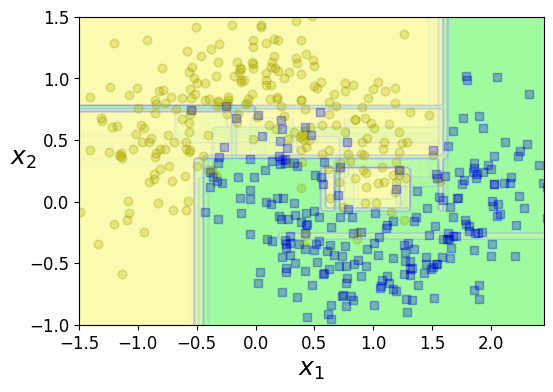

In [23]:
plt.figure(figsize=(6, 4))

for i in range(15):
    tree_clf = DecisionTreeClassifier(max_leaf_nodes=16, random_state=42 + i)
    indices_with_replacement = np.random.randint(0, len(X_train), len(X_train))
    tree_clf.fit(X[indices_with_replacement], y[indices_with_replacement])
    plot_decision_boundary(tree_clf, X, y, axes=[-1.5, 2.45, -1, 1.5], alpha=0.02, contour=False)

plt.show()

# AdaBoost

**부스팅(Boosting)**은 약한 예측기를 순차적으로 학습하여 결합하는 방법으로, 이전 예측기의 오차를 보정하는 방향으로 다음 예측기를 학습한다.

**AdaBoost(Adaptive Boosting)**는 각 반복에서 오분류된 샘플의 가중치를 증가시켜 다음 예측기가 이를 더 비중 있게 학습하도록 하고, 예측기별 성능에 따라 가중치를 부여하여 가중 다수결로 최종 예측을 결정한다. 배깅이 분산을 줄이는 반면, 부스팅은 주로 편향(bias)을 감소시킨다.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=200, learning_rate=0.5, random_state=42)
ada_clf.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=200, random_state=42)

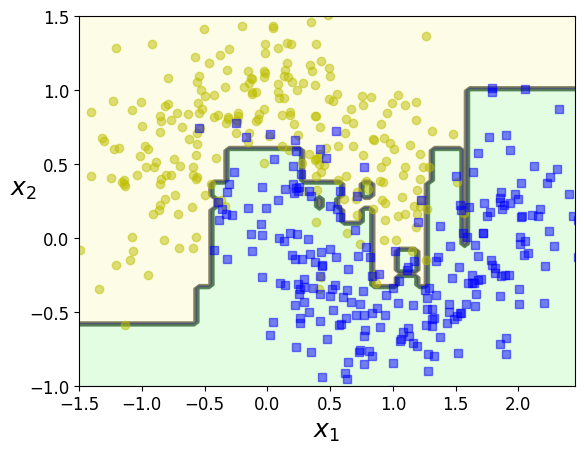

In [ ]:
plot_decision_boundary(ada_clf, X, y)


# Exercise

**연습.** 타이타닉 데이터에서 `Survived`를 타깃 $y$로, 나머지 열을 특성 $X$로 하여 `DecisionTreeClassifier`를 학습하고 `model`에 저장한 뒤, 아래 코드로 트리를 시각화하라.

In [ ]:
import pandas as pd
titanic = pd.read_csv('https://web.stanford.edu/class/archive' \
                      '/cs/cs109/cs109.1166/stuff/titanic.csv')
titanic

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.0000
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.4500
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.0000


In [ ]:
# drop string value
titanic.drop('Name', axis=1, inplace=True)
titanic.drop('Sex', axis=1, inplace=True)

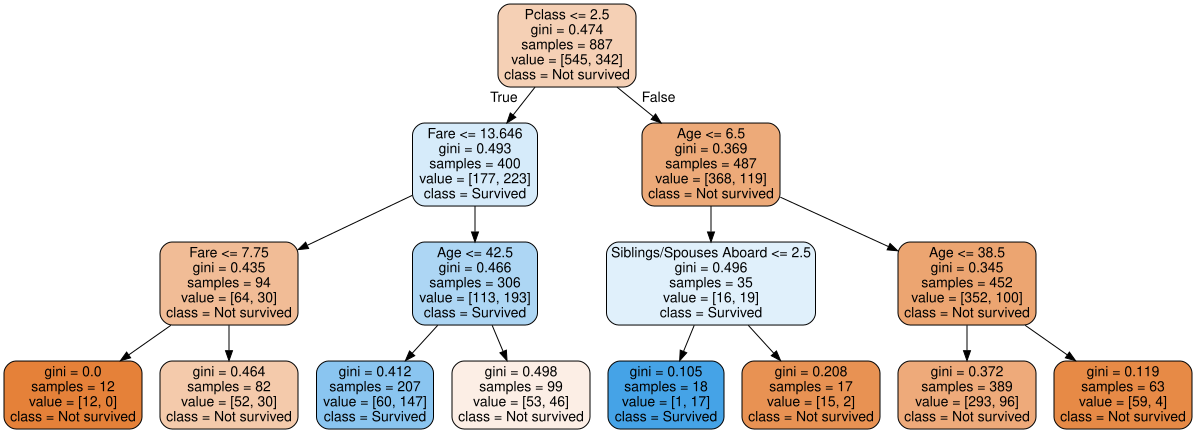

In [ ]:
from sklearn import tree
from graphviz import Source

# To-do
# Survived를 y에 저장, Survived를 제외한 나머지 column들을 X로 사용
# Decision Tree Classifier 학습 : model에 저장


graph = Source(tree.export_graphviz(model, out_file=None,
                                    feature_names=titanic.columns[1:],
                                    class_names=['Not survived', 'Survived'],
                                    filled=True, rounded=True))
graph